In [1]:
!pip install kaggle

In [2]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

I0000 00:00:1773641017.242552   85095 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1773641017.310068   85095 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


I0000 00:00:1773641021.811390   85095 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [8]:
!mkdir -p ~/.kaggle

In [9]:
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [10]:
!kaggle datasets list

ref                                                          title                                                     size  lastUpdated                 downloadCount  voteCount  usabilityRating  
-----------------------------------------------------------  --------------------------------------------------  ----------  --------------------------  -------------  ---------  ---------------  
dmahajanbe23/bmw-global-automotive-sales                     BMW Global Automotive Sales                              55017  2026-02-22 18:18:38.170000           8781        170                1  
jayjoshi37/sleep-screen-time-and-stress-analysis             Sleep, Screen Time and Stress Analysis                  310158  2026-03-11 14:21:59.017000           1141         26                1  
ssssws/chocolate-sales-dataset-2023-2024                     Chocolate Sales Dataset 2023 - 2024                   24420255  2026-03-07 04:58:02.387000           2429         51                1  
shree0910/ai-an

In [11]:
#!/bin/bash
!kaggle datasets download tongpython/cat-and-dog

Dataset URL: https://www.kaggle.com/datasets/tongpython/cat-and-dog
License(s): CC0-1.0
 25%|██████████                              | 55.0M/218M [00:00<00:00, 200MB/s]

100%|█████████████████████████████████████████| 218M/218M [00:01<00:00, 190MB/s]



In [12]:
import zipfile

zip_ref = zipfile.ZipFile("cat-and-dog.zip")
zip_ref.extractall("dataset")
zip_ref.close()

In [13]:
import tensorflow as tf

train_data = tf.keras.utils.image_dataset_from_directory(
    "dataset/training_set/training_set",
    image_size=(150,150),
    batch_size=32
)

Found 8005 files belonging to 2 classes.


I0000 00:00:1773641347.374901   85095 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:1e.0, compute capability: 7.5


In [14]:
test_data = tf.keras.utils.image_dataset_from_directory(
    "dataset/test_set/test_set",
    image_size=(150,150),
    batch_size=32
)

Found 2023 files belonging to 2 classes.


In [15]:
train_data = train_data.map(lambda x,y: (x/255, y))
test_data = test_data.map(lambda x,y: (x/255, y))

In [17]:
for images, labels in train_data.take(1):
    print(images.shape)
    print(labels)

(32, 150, 150, 3)
tf.Tensor([1 0 1 0 1 1 0 1 1 1 1 1 1 1 0 1 0 1 1 0 0 0 1 1 0 0 0 0 0 0 0 0], shape=(32,), dtype=int32)


In [18]:
from tensorflow.keras import layers
from tensorflow.keras import models

In [19]:
model = models.Sequential([
    
    # First Convolution Layer
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(150,150,3)),
    layers.MaxPooling2D((2,2)),

    # Second Convolution Layer
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),

    # Third Convolution Layer
    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),

    # Flatten Layer
    layers.Flatten(),

    # Dense Layer
    layers.Dense(128, activation='relu'),

    # Output Layer
    layers.Dense(1, activation='sigmoid')
])

/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [20]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 36992)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     4,735,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,828,481 (18.42 MB)

 Trainable params: 4,828,481 (18.42 MB)

 Non-trainable params: 0 (0.00 B)

In [21]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [22]:
history = model.fit(
    train_data,
    epochs=20,
    validation_data=test_data
)

Epoch 1/20


I0000 00:00:1773641384.414455  103831 service.cc:153] XLA service 0x7a80300038c0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1773641384.414485  103831 service.cc:161]   StreamExecutor [0]: Tesla T4, Compute Capability 7.5 (Driver: 12.8.0; Runtime: 12.8.0; Toolkit: 12.5.0; DNN: 9.10.2)
I0000 00:00:1773641384.585212  103831 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1773641385.083683  103831 cuda_dnn.cc:461] Loaded cuDNN version 91002
I0000 00:00:1773641385.132807  103831 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_2073__.35


  7/251 ━━━━━━━━━━━━━━━━━━━━ 5s 24ms/step - accuracy: 0.4121 - loss: 0.9624

I0000 00:00:1773641390.251392  103831 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


248/251 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.5470 - loss: 0.7063

I0000 00:00:1773641396.657243  103831 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_2073__.35
E0000 00:00:1773641397.877058  103831 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


251/251 ━━━━━━━━━━━━━━━━━━━━ 21s 54ms/step - accuracy: 0.6017 - loss: 0.6597 - val_accuracy: 0.7009 - val_loss: 0.5873
Epoch 2/20
251/251 ━━━━━━━━━━━━━━━━━━━━ 7s 29ms/step - accuracy: 0.7197 - loss: 0.5528 - val_accuracy: 0.6866 - val_loss: 0.5985
Epoch 3/20
251/251 ━━━━━━━━━━━━━━━━━━━━ 8s 31ms/step - accuracy: 0.7644 - loss: 0.4839 - val_accuracy: 0.7435 - val_loss: 0.5202
Epoch 4/20
251/251 ━━━━━━━━━━━━━━━━━━━━ 8s 31ms/step - accuracy: 0.8150 - loss: 0.3960 - val_accuracy: 0.7523 - val_loss: 0.5467
Epoch 5/20
251/251 ━━━━━━━━━━━━━━━━━━━━ 7s 27ms/step - accuracy: 0.8671 - loss: 0.3059 - val_accuracy: 0.7558 - val_loss: 0.6016
Epoch 6/20
251/251 ━━━━━━━━━━━━━━━━━━━━ 7s 27ms/step - accuracy: 0.9097 - loss: 0.2188 - val_accuracy: 0.7672 - val_loss: 0.7492
Epoch 7/20
251/251 ━━━━━━━━━━━━━━━━━━━━ 7s 27ms/step - accuracy: 0.9442 - loss: 0.1399 - val_accuracy: 0.7687 - val_loss: 0.8506
Epoch 8/20
251/251 ━━━━━━━━━━━━━━━━━━━━ 7s 27ms/step - accuracy: 0.9668 - loss: 0.0878 - val_accuracy: 0.75

In [23]:
model.save("cats_dogs_cnn_model.h5")

In [27]:
model.evaluate(test_data)

21/64 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.7728 - loss: 1.6831

64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.7439 - loss: 1.9321


[1.9321173429489136, 0.7439446449279785]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step


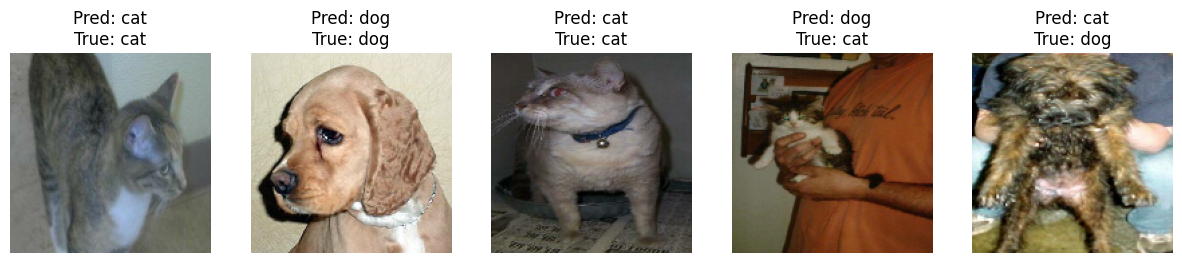

In [28]:
import matplotlib.pyplot as plt
import numpy as np

class_names = ['cat','dog']

for images, labels in test_data.take(1):

    predictions = model.predict(images)

    plt.figure(figsize=(15,5))

    for i in range(5):

        plt.subplot(1,5,i+1)

        img = (images[i].numpy()*255).astype("uint8")

        plt.imshow(img)

        pred_label = class_names[int(predictions[i][0] > 0.5)]
        true_label = class_names[int(labels[i])]

        plt.title(f"Pred: {pred_label}\nTrue: {true_label}")
        plt.axis("off")

plt.show()

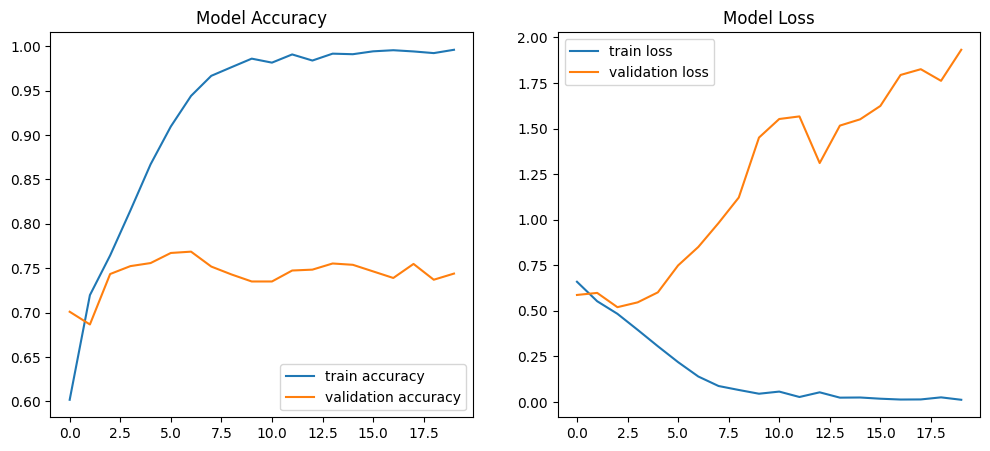

In [29]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

# Accuracy
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='train accuracy')
plt.plot(history.history['val_accuracy'], label='validation accuracy')
plt.title("Model Accuracy")
plt.legend()

# Loss
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='validation loss')
plt.title("Model Loss")
plt.legend()

plt.show()

In [35]:
from tensorflow.keras.preprocessing import image
import numpy as np

img = image.load_img("/teamspace/studios/this_studio/Cat_vs_Dog/CNN_Project/dataset/test_set/test_set/cats/cat.4011.jpg", target_size=(150,150))
img_array = image.img_to_array(img)

img_array = np.expand_dims(img_array, axis=0)
img_array = img_array / 255

prediction = model.predict(img_array)

if prediction[0][0] > 0.5:
    print("Dog")
else:
    print("Cat")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
Cat


In [27]:
mkdir templates

In [36]:
mkdir .streamlit

In [30]:
touch .streamlit/config.toml

NameError: name 'touch' is not defined